# AlphaProof RL run explorer

This notebook loads every persisted artifact from one RL run, the matching LSF log, and the local W&B history/system telemetry. Change only `RUN_DIR` in the first code cell to inspect another run.

Timing interpretation used throughout:

- **GPU inference:** `tactic_generation.total_seconds` (`Network.sample`).
- **Lean / CPU:** theorem setup, tactic execution, final proof verification, and the fixed-theorem validation phase. Validation is classified as CPU-dominated rather than purely CPU because its individual games were not written to `timings.jsonl`; the GPU-utilization plots make this assumption visible.
- **GPU training:** learner-phase wall time inferred from timestamped W&B learner events.
- Phase boundaries use the type of the next timestamped event. This matches the sequential actor → validation → learner loop, but it remains an inference rather than an explicit phase timer.


In [1]:
import json
import re
from bisect import bisect_left
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from wandb.proto import wandb_internal_pb2
from wandb.sdk.internal.datastore import DataStore


# EDIT THIS PATH TO VISUALIZE ANOTHER RUN.
RUN_DIR = Path('data/runs/rl_codet5p_220m_v100_32gb_04')

# Paths are resolved correctly whether the kernel starts in the repo root or scripts/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'scripts':
    PROJECT_ROOT = PROJECT_ROOT.parent
RUN_DIR = (PROJECT_ROOT / RUN_DIR).resolve() if not RUN_DIR.is_absolute() else RUN_DIR.resolve()
RUN_NAME = RUN_DIR.name

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 120})

print(f'Run: {RUN_NAME}')
print(f'Path: {RUN_DIR}')


Run: rl_codet5p_220m_v100_32gb_04
Path: /work3/s204164/mini-alphaproof/data/runs/rl_codet5p_220m_v100_32gb_04


## Load and normalize all artifacts

The loader keeps the raw JSON records and also creates analysis-friendly tables for games, node expansions, tactics/actions, replay entries, validation passes, theorem matchmaker state, learner history, system telemetry, checkpoints, and the LSF resource footer.


In [2]:
def load_json(path):
    with path.open(encoding='utf-8') as file:
        return json.load(file)


def load_jsonl(path):
    with path.open(encoding='utf-8') as file:
        return [json.loads(line) for line in file if line.strip()]


def wandb_item_key(item):
    return item.key or '.'.join(item.nested_key)


def load_wandb_records(path):
    store = DataStore()
    store.open_for_scan(str(path))
    history = []
    system = []
    while data := store.scan_data():
        record = wandb_internal_pb2.Record()
        record.ParseFromString(data)
        record_type = record.WhichOneof('record_type')
        if record_type == 'history':
            history.append({
                wandb_item_key(item): json.loads(item.value_json)
                for item in record.history.item
            })
        elif record_type == 'stats':
            row = {
                item.key: json.loads(item.value_json)
                for item in record.stats.item
            }
            row['_timestamp'] = (
                record.stats.timestamp.seconds
                + record.stats.timestamp.nanos / 1e9
            )
            system.append(row)
    return pd.DataFrame(history), pd.DataFrame(system)


def find_lsf_log(project_root, run_name):
    candidates = sorted(
        (project_root / 'scripts/batch/logs').glob('rl_*.out'),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    return next(
        path for path in candidates
        if run_name in path.read_text(encoding='utf-8', errors='replace')
    )


def parse_lsf_resources(text):
    names = ('CPU time', 'Max Memory', 'Average Memory', 'Total Requested Memory', 'Run time', 'Turnaround time')
    resources = {}
    for name in names:
        match = re.search(rf'{re.escape(name)}\s*:\s*([0-9.]+)', text)
        resources[name] = float(match.group(1))
    resources['exit_reason'] = next(
        line.strip() for line in text.splitlines()
        if line.startswith('TERM_')
    )
    return resources


config_paths = {int(path.stem.removeprefix('config_')): path for path in RUN_DIR.glob('config_*.json')}
config = load_json(config_paths[max(config_paths)])
status = load_json(RUN_DIR / 'status.json')
timing_records = load_jsonl(RUN_DIR / 'timings.jsonl')
results = pd.DataFrame(load_jsonl(RUN_DIR / 'results.jsonl'))
replay = pd.DataFrame(load_jsonl(RUN_DIR / 'replay_buffer.jsonl'))
validation = pd.DataFrame(load_jsonl(RUN_DIR / 'validation_results.jsonl'))
matchmaker = load_json(RUN_DIR / 'matchmaker_stats.json')['theorem_stats']

wandb_id = config['wandb_run_id']
wandb_file = next(PROJECT_ROOT.glob(f'data/wandb/run-*-{wandb_id}/run-{wandb_id}.wandb'))
history, system_raw = load_wandb_records(wandb_file)
lsf_log = find_lsf_log(PROJECT_ROOT, RUN_NAME)
lsf_text = lsf_log.read_text(encoding='utf-8', errors='replace')
lsf_resources = parse_lsf_resources(lsf_text)

print(f'W&B file: {wandb_file.relative_to(PROJECT_ROOT)}')
print(f'LSF log:   {lsf_log.relative_to(PROJECT_ROOT)}')


W&B file: data/wandb/run-20260725_183125-6eeef6871e814426b7d43bef880282aa/run-6eeef6871e814426b7d43bef880282aa.wandb
LSF log:   scripts/batch/logs/rl_codet5p_220m_28959336.out


In [3]:
game_rows = []
expansion_rows = []
tactic_rows = []
for record in timing_records:
    verification = record['final_verification']
    game_rows.append({
        'game': record['game'],
        'success': record['success'],
        'disprove': record['disprove'],
        'theorem': record['theorem'],
        'total_seconds': record['total_seconds'],
        'setup_seconds': record['setup_seconds'],
        'generation_seconds': record['tactic_generation']['total_seconds'],
        'generation_count': record['tactic_generation']['count'],
        'execution_seconds': record['tactic_execution']['total_seconds'],
        'execution_count': record['tactic_execution']['count'],
        'internal_seconds': record['internal_actions']['total_seconds'],
        'internal_count': record['internal_actions']['count'],
        'verification_seconds': 0.0 if verification is None else verification['seconds'],
        'verifier_startup_seconds': 0.0 if verification is None else verification['verifier_startup_seconds'],
        'was_verified': verification is not None,
    })
    for expansion in record['tactic_generation']['expansions']:
        expansion_rows.append({'game': record['game'], **expansion})
    for tactic in record['tactic_execution']['tactics']:
        tactic_rows.append({'game': record['game'], **tactic})

games = pd.DataFrame(game_rows)
games['other_seconds'] = (
    games['total_seconds']
    - games[['setup_seconds', 'generation_seconds', 'execution_seconds', 'internal_seconds', 'verification_seconds']].sum(axis=1)
).clip(lower=0)
expansions = pd.DataFrame(expansion_rows)
tactics = pd.DataFrame(tactic_rows)
tactics['average_seconds'] = tactics['total_seconds'] / tactics['count']
tactics['success_rate'] = tactics['successful_count'] / tactics['count']

matchmaker_rows = []
for theorem_record in matchmaker:
    attempts = theorem_record['attempts']
    matchmaker_rows.append({
        'theorem': theorem_record['theorem'],
        'invalid': theorem_record['invalid'],
        'attempts': len(attempts),
        'prove_attempts': sum(not disprove for disprove, _ in attempts),
        'disprove_attempts': sum(disprove for disprove, _ in attempts),
        'successes': sum(success for _, success in attempts),
    })
matchmaker_df = pd.DataFrame(matchmaker_rows)

system_raw['timestamp'] = pd.to_datetime(system_raw['_timestamp'], unit='s')
system = system_raw.groupby(system_raw['timestamp'].dt.round('s'), as_index=False).first()

def event_type(row):
    if pd.notna(row.get('actor/game')):
        return 'actor'
    if pd.notna(row.get('learner/step')):
        return 'learner'
    if pd.notna(row.get('validation/game')):
        return 'validation'
    return None

events = history.loc[history.apply(event_type, axis=1).notna()].copy()
events['phase'] = events.apply(event_type, axis=1)
events = events.sort_values('_timestamp')
events['phase_seconds'] = events['_runtime'].diff().fillna(events['_runtime'])
phase_times = events.groupby('phase')['phase_seconds'].sum().sort_values(ascending=False)

event_times = events['_timestamp'].to_numpy()
event_phases = events['phase'].to_numpy()
system['phase'] = [
    event_phases[index] if index < len(event_phases) else 'after_last_event'
    for index in (bisect_left(event_times, value) for value in system['_timestamp'])
]

checkpoints = pd.DataFrame([
    {'checkpoint': path.name, 'step': int(path.stem.removeprefix('step_')), 'size_gb': path.stat().st_size / 1e9}
    for path in sorted((RUN_DIR / 'checkpoints').glob('step_*.pt'))
])


## Artifact inventory and run configuration


In [4]:
artifact_rows = []
for path in sorted(RUN_DIR.iterdir()):
    if path.is_file():
        artifact_rows.append({'artifact': path.name, 'size_mb': path.stat().st_size / 1e6})
artifact_rows.extend([
    {'artifact': 'W&B local binary', 'size_mb': wandb_file.stat().st_size / 1e6},
    {'artifact': 'LSF stdout', 'size_mb': lsf_log.stat().st_size / 1e6},
])
print(pd.DataFrame(artifact_rows).to_string(index=False, formatters={'size_mb': '{:.2f}'.format}))
print('\nStatus at termination:')
print(json.dumps(status, indent=2)[:2000])
print('\nCore configuration:')
config_names = [
    'dataset_dir', 'num_games', 'num_simulations', 'num_sampled_actions',
    'tactic_timeout', 'final_check_timeout', 'training_steps',
    'training_iterations', 'batch_size', 'validation_interval',
    'theorem_validation_interval_games', 'theorem_validation_num_theorems',
]
print(pd.Series({name: config['config'][name] for name in config_names}).to_string())
print('\nLSF resource summary:')
print(pd.Series(lsf_resources).to_string())
print('\nCheckpoints:')
print(checkpoints.to_string(index=False))


                artifact size_mb
             config.json    0.00
               crash.log    0.00
   matchmaker_stats.json   33.27
     replay_buffer.jsonl    0.01
           results.jsonl    0.16
             status.json    0.00
           timings.jsonl   29.98
validation_results.jsonl    0.00
validation_theorems.json    0.01
        W&B local binary    5.64
              LSF stdout    0.13

Status at termination:
{
  "state": "running",
  "phase": "actor",
  "game": 207,
  "theorem": "open Real\ntheorem algebra_152362 (\u03b1 \u03b2 \u03b3 : \u211d) (h : \u03b1 + \u03b2 + \u03b3 = \u03c0 / 2) (h1 : \u2200 (k : \u2124), \u03b1 \u2260 (2 * \u2191k + 1) * \u03c0 / 2) (h2 : \u2200 (k : \u2124), \u03b2 \u2260 (2 * \u2191k + 1) * \u03c0 / 2) (h3 : \u2200 (k : \u2124), \u03b3 \u2260 (2 * \u2191k + 1) * \u03c0 / 2):\n    tan \u03b1 * tan \u03b2 + tan \u03b2 * tan \u03b3 + tan \u03b1 * tan \u03b3 = 1 := by sorry",
  "timestamp": "2026-07-26T18:24:21.833343+02:00",
  "pid": 1029624
}

Core co

## Where wall time went: CPU/Lean versus GPU

The first chart uses timestamped W&B phase boundaries. The second uses exact actor-game timers. The final table combines both into the resource-oriented estimate used to answer the CPU-versus-GPU question.


                          seconds hours percent
Lean / CPU-dominated     51,918.0 14.42   60.4%
GPU inference + training 32,989.4  9.16   38.4%
Unclassified overhead     1,067.8  0.30    1.2%

Whole-run phases:
phase
actor        16.76
validation    5.71
learner       1.41

Exact actor components:
                        hours actor_percent
GPU tactic inference     7.75         47.0%
Lean tactic execution    4.53         27.5%
Lean setup               4.03         24.5%
Lean final verification  0.16          1.0%
Other actor work         0.01          0.0%
Internal actions         0.00          0.0%


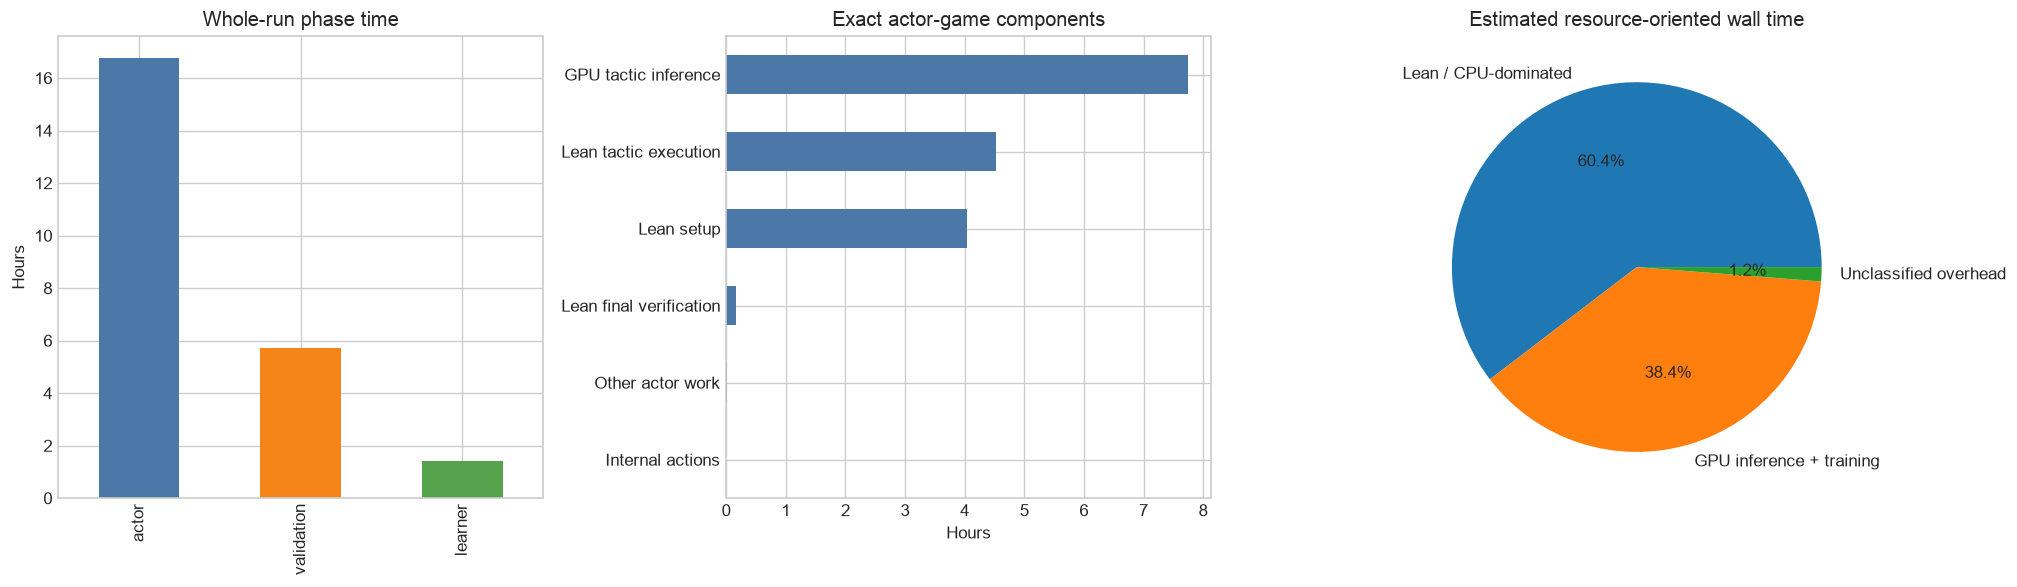

In [5]:
component_seconds = pd.Series({
    'Lean setup': games['setup_seconds'].sum(),
    'GPU tactic inference': games['generation_seconds'].sum(),
    'Lean tactic execution': games['execution_seconds'].sum(),
    'Lean final verification': games['verification_seconds'].sum(),
    'Internal actions': games['internal_seconds'].sum(),
    'Other actor work': games['other_seconds'].sum(),
}).sort_values(ascending=False)

lean_actor_seconds = component_seconds[['Lean setup', 'Lean tactic execution', 'Lean final verification']].sum()
gpu_actor_seconds = component_seconds['GPU tactic inference']
validation_seconds = phase_times.get('validation', 0.0)
learner_seconds = phase_times.get('learner', 0.0)
profiled_runtime = events['_runtime'].max()
resource_seconds = pd.Series({
    'Lean / CPU-dominated': lean_actor_seconds + validation_seconds,
    'GPU inference + training': gpu_actor_seconds + learner_seconds,
})
resource_seconds['Unclassified overhead'] = max(0.0, profiled_runtime - resource_seconds.sum())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
(phase_times / 3600).plot.bar(ax=axes[0], color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].set(title='Whole-run phase time', ylabel='Hours', xlabel='')
(component_seconds / 3600).sort_values().plot.barh(ax=axes[1], color='#4c78a8')
axes[1].set(title='Exact actor-game components', xlabel='Hours', ylabel='')
(resource_seconds / 3600).plot.pie(ax=axes[2], autopct='%1.1f%%', ylabel='')
axes[2].set_title('Estimated resource-oriented wall time')
plt.tight_layout()

summary = pd.DataFrame({'seconds': resource_seconds})
summary['hours'] = summary['seconds'] / 3600
summary['percent'] = 100 * summary['seconds'] / summary['seconds'].sum()
print(summary.to_string(formatters={'seconds': '{:,.1f}'.format, 'hours': '{:.2f}'.format, 'percent': '{:.1f}%'.format}))
print('\nWhole-run phases:')
print((phase_times / 3600).rename('hours').to_string(float_format='{:.2f}'.format))
print('\nExact actor components:')
print(pd.DataFrame({'hours': component_seconds / 3600, 'actor_percent': 100 * component_seconds / games['total_seconds'].sum()}).to_string(formatters={'hours': '{:.2f}'.format, 'actor_percent': '{:.1f}%'.format}))


## System utilization over time and by phase

W&B sampled CPU and GPU stats in separate records; they are merged by rounded timestamp above. Host `cpu` is node-wide utilization, while `gpu.0.gpu` is the allocated GPU's utilization percentage.


                  gpu.0.gpu  gpu.0.memory  gpu.0.powerWatts  cpu  proc.memory.rssMB
phase                                                                              
actor                  12.2           3.8              47.2 13.1             5000.1
after_last_event       13.7           4.3              44.1 12.6             5200.8
learner                97.9          50.8             199.2 13.2             4474.5
validation             11.5           3.6              46.6 13.0             4419.6


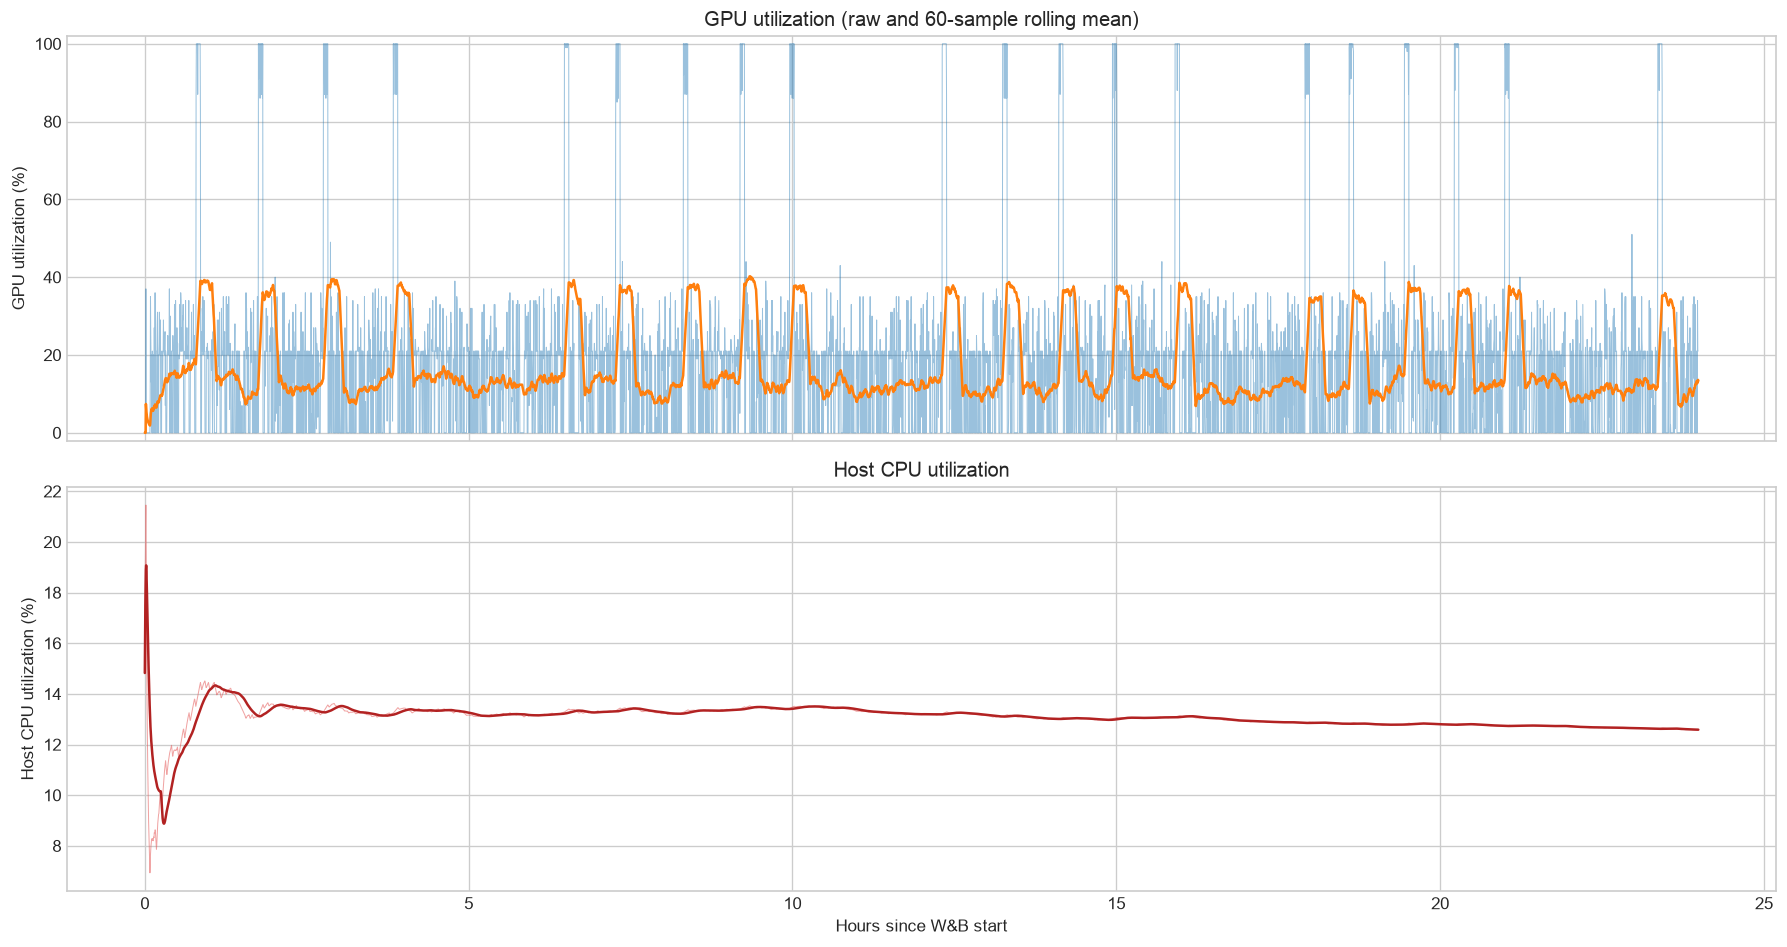

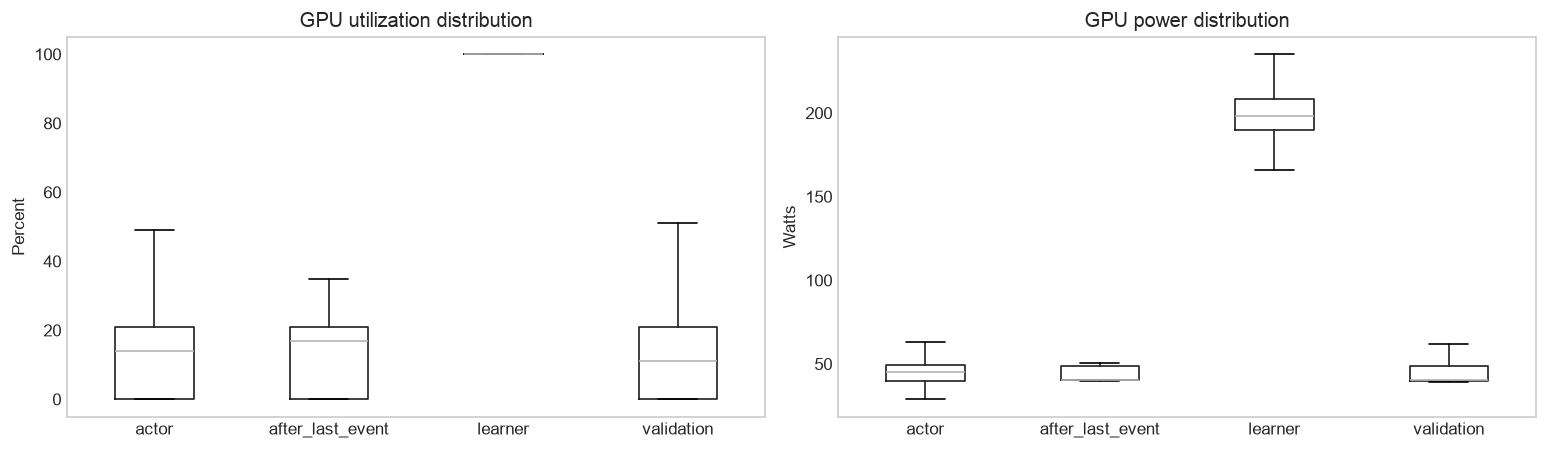

In [6]:
system['hours'] = (system['_timestamp'] - system['_timestamp'].min()) / 3600
utilization_columns = ['gpu.0.gpu', 'gpu.0.memory', 'gpu.0.powerWatts', 'cpu', 'proc.memory.rssMB']
available_utilization = [column for column in utilization_columns if column in system.columns]
phase_utilization = system.groupby('phase')[available_utilization].mean()
print(phase_utilization.to_string(float_format='{:.1f}'.format))

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(system['hours'], system['gpu.0.gpu'], linewidth=0.6, alpha=0.45)
axes[0].plot(system['hours'], system['gpu.0.gpu'].rolling(60, min_periods=1).mean(), linewidth=1.5)
axes[0].set(ylabel='GPU utilization (%)', title='GPU utilization (raw and 60-sample rolling mean)', ylim=(-2, 102))
axes[1].plot(system['hours'], system['cpu'], color='#e45756', linewidth=0.6, alpha=0.55)
axes[1].plot(system['hours'], system['cpu'].rolling(60, min_periods=1).mean(), color='#b22222', linewidth=1.5)
axes[1].set(xlabel='Hours since W&B start', ylabel='Host CPU utilization (%)', title='Host CPU utilization')
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
phase_order = [phase for phase in ('actor', 'validation', 'learner') if phase in system['phase'].unique()]
system.boxplot(column='gpu.0.gpu', by='phase', ax=axes[0], showfliers=False, grid=False)
axes[0].set(title='GPU utilization distribution', xlabel='', ylabel='Percent')
system.boxplot(column='gpu.0.powerWatts', by='phase', ax=axes[1], showfliers=False, grid=False)
axes[1].set(title='GPU power distribution', xlabel='', ylabel='Watts')
plt.suptitle('')
plt.tight_layout()


## Game outcomes and per-game timing


Timing quantiles (seconds):
      total_seconds  setup_seconds  generation_seconds  execution_seconds  verification_seconds
0.50         279.78          70.15              134.52              66.29                  0.00
0.90         416.63          73.12              212.57             150.45                  0.00
0.95         460.45          74.51              251.25             197.64                  0.30
0.99         605.05          79.35              308.09             329.73                 72.14
1.00         769.64          87.22              345.64             492.47                 73.93

Slowest games:
 game  success  total_seconds  setup_seconds  generation_seconds  execution_seconds  verification_seconds  generation_count  execution_count                                                                                                                                                                                                                                                

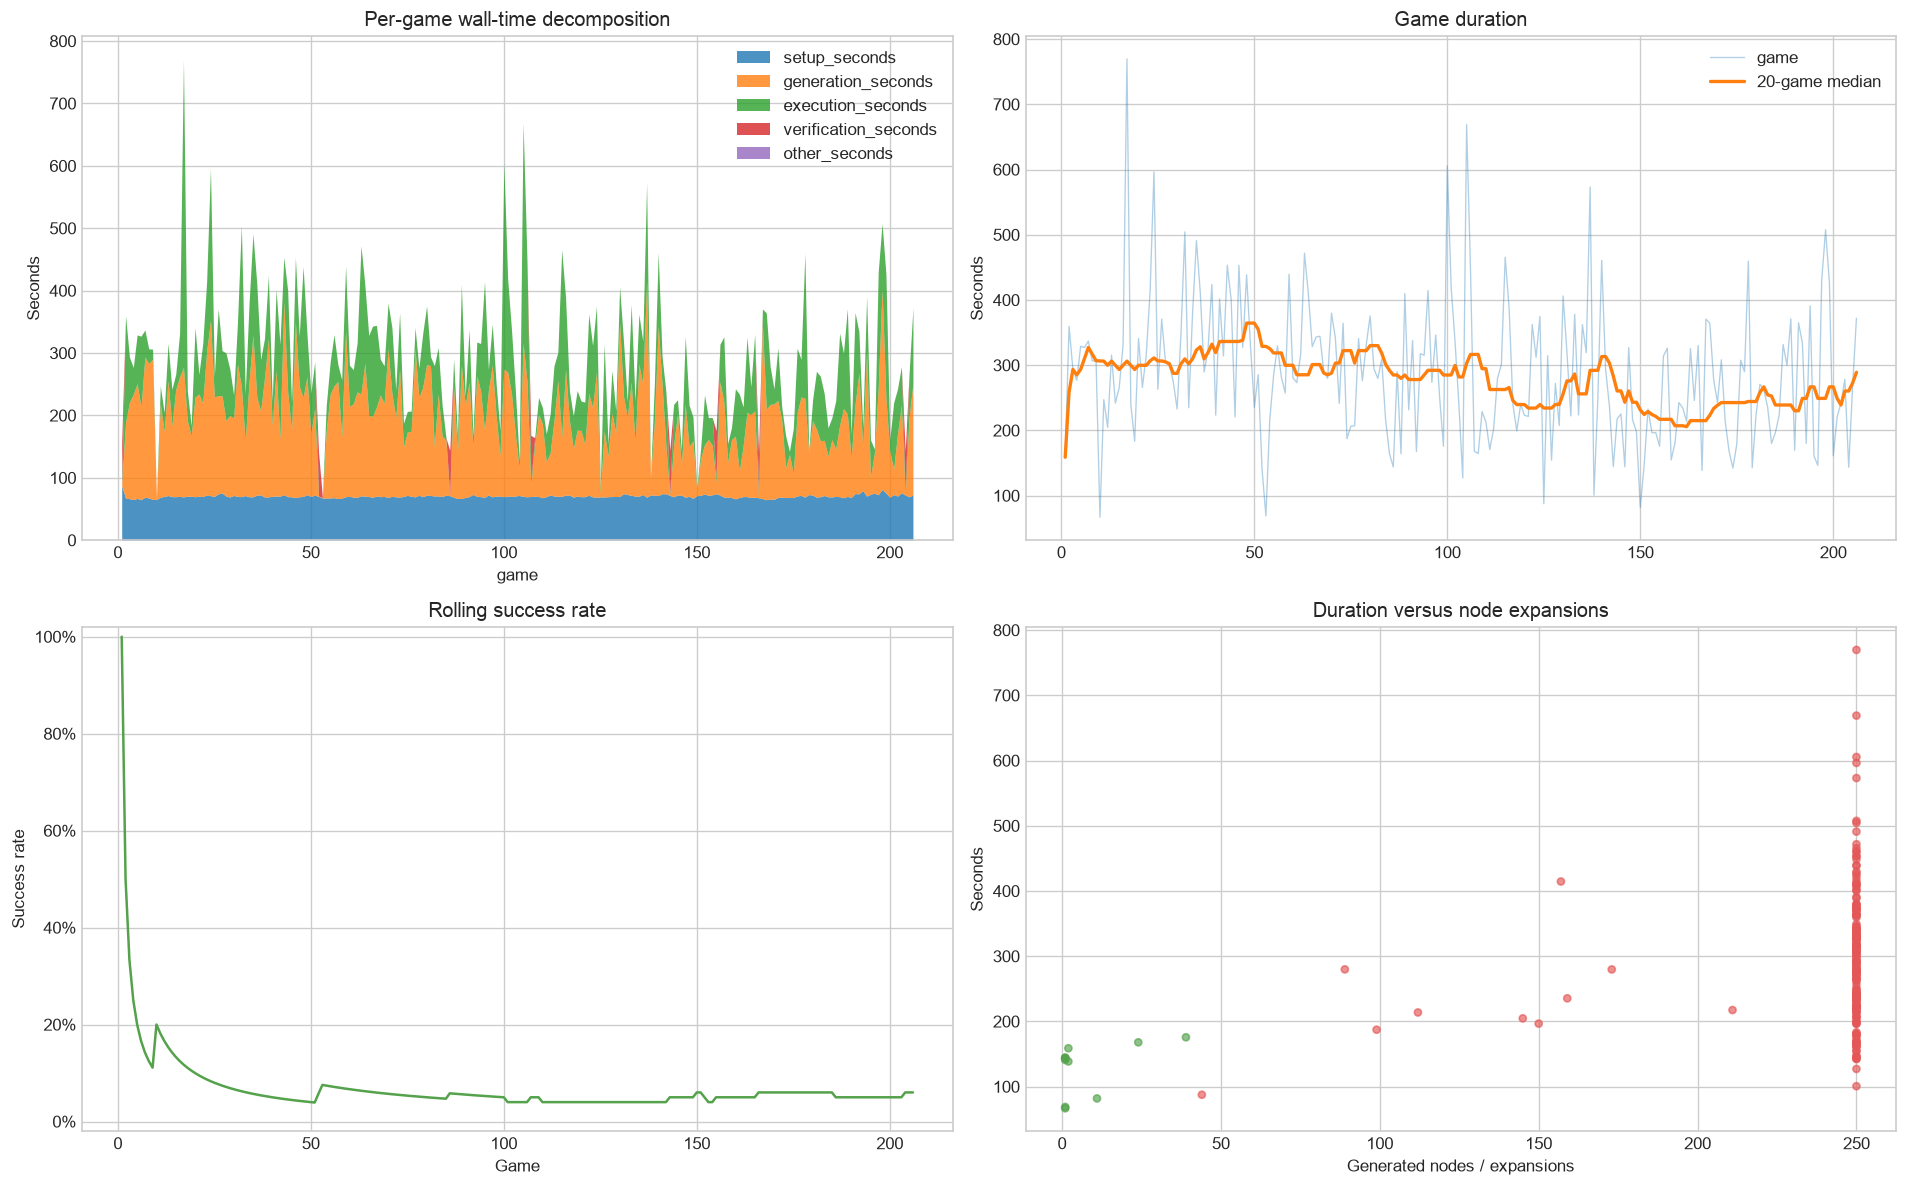

In [7]:
merged_games = games.merge(
    results[['game', 'rolling_success_rate', 'rolling_average_reward', 'episode_reward', 'num_simulations', 'replay_size', 'error']],
    on='game',
    how='left',
)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
stack_columns = ['setup_seconds', 'generation_seconds', 'execution_seconds', 'verification_seconds', 'other_seconds']
merged_games.set_index('game')[stack_columns].plot.area(ax=axes[0, 0], linewidth=0, alpha=0.8)
axes[0, 0].set(title='Per-game wall-time decomposition', ylabel='Seconds')
axes[0, 1].plot(merged_games['game'], merged_games['total_seconds'], alpha=0.35, linewidth=0.8, label='game')
axes[0, 1].plot(merged_games['game'], merged_games['total_seconds'].rolling(20, min_periods=1).median(), linewidth=2, label='20-game median')
axes[0, 1].set(title='Game duration', ylabel='Seconds')
axes[0, 1].legend()
axes[1, 0].plot(merged_games['game'], merged_games['rolling_success_rate'], color='#54a24b')
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 0].set(title='Rolling success rate', xlabel='Game', ylabel='Success rate', ylim=(-0.02, 1.02))
colors = merged_games['success'].map({0: '#e45756', 1: '#54a24b'})
axes[1, 1].scatter(merged_games['generation_count'], merged_games['total_seconds'], c=colors, alpha=0.65, s=18)
axes[1, 1].set(title='Duration versus node expansions', xlabel='Generated nodes / expansions', ylabel='Seconds')
plt.tight_layout()

game_quantiles = games[['total_seconds', 'setup_seconds', 'generation_seconds', 'execution_seconds', 'verification_seconds']].quantile([0.5, 0.9, 0.95, 0.99, 1.0])
print('Timing quantiles (seconds):')
print(game_quantiles.to_string(float_format='{:.2f}'.format))
print('\nSlowest games:')
print(merged_games.nlargest(15, 'total_seconds')[['game', 'success', 'total_seconds', 'setup_seconds', 'generation_seconds', 'execution_seconds', 'verification_seconds', 'generation_count', 'execution_count', 'theorem']].to_string(index=False))
print('\nErrors:')
print(merged_games['error'].fillna('No error').value_counts().head(20).to_string())


## Inference / node-expansion latency

Each row is one call to tactic generation at a newly expanded search node.


             count  mean  median   max
num_tactics                           
1             3402 0.135   0.112 0.742
2             4132 0.249   0.214 2.719
3             5275 0.350   0.273 2.722
4             6674 0.456   0.343 2.716
5             8853 0.587   0.465 2.724
6            19337 0.844   0.723 2.739

Slowest inference calls:
 game  expansion  simulation  state_id  seconds  num_tactics
  176          1           1         0 2.738703            6
  198        222         222        66 2.728303            6
  116        145         145        89 2.727211            6
  109         34          34        22 2.727203            6
  137         74          74        40 2.726901            6
  137         91          91        49 2.726415            6
  137         67          67        38 2.726259            6
  137         94          94        50 2.725921            6
  198         69          69        26 2.725539            6
  137          9           9         2 2.725299     

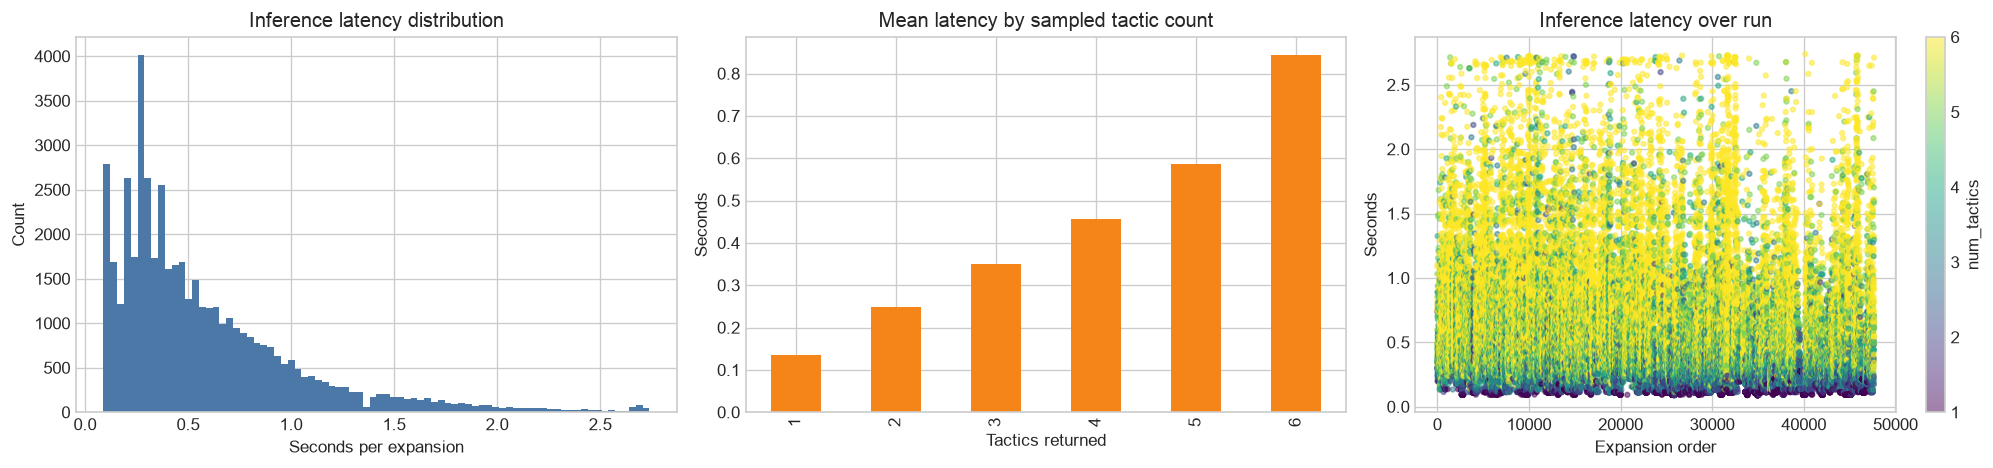

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(expansions['seconds'], bins=80, color='#4c78a8')
axes[0].set(title='Inference latency distribution', xlabel='Seconds per expansion', ylabel='Count')
expansion_by_outputs = expansions.groupby('num_tactics')['seconds'].agg(['count', 'mean', 'median', 'max'])
expansion_by_outputs['mean'].plot.bar(ax=axes[1], color='#f58518')
axes[1].set(title='Mean latency by sampled tactic count', xlabel='Tactics returned', ylabel='Seconds')
expansions.assign(order=np.arange(len(expansions))).plot.scatter(x='order', y='seconds', c='num_tactics', cmap='viridis', s=8, alpha=0.5, ax=axes[2])
axes[2].set(title='Inference latency over run', xlabel='Expansion order', ylabel='Seconds')
plt.tight_layout()
print(expansion_by_outputs.to_string(float_format='{:.3f}'.format))
print('\nSlowest inference calls:')
print(expansions.nlargest(20, 'seconds').to_string(index=False))


## Lean tactic/action execution

`timings.jsonl` stores per-game aggregates for identical tactic strings. `average_seconds`, `min_seconds`, and `max_seconds` therefore describe each executed action accurately; most generated tactic strings occur only once per game.


/work3/s204164/tmp/ipykernel_2484879/4029690752.py:20: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/work3/s204164/tmp/ipykernel_2484879/4029690752.py:20: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


All individual per-game action aggregates, slowest first:
 game                                                                                                                                                  tactic  count  successful_count  total_seconds  average_seconds  min_seconds  max_seconds
   50                                                                                                            have hdc : b < d := Nat.cast_pos.2 hdist.2.1      1                 0       7.349226         7.349226     7.349226     7.349226
   74              simp only [Nat.digitsAux 10, Nat.succ_div, Nat.pow_succ, ← hp3, Nat.mul_add,\n        Nat.add_div (Nat.prime_pos hp2), Nat.add_right_comm]      1                 0       7.349206         7.349206     7.349206     7.349206
   84                                                                                                                                         specialize hz h      1                 0       7.044275         7.044275     

/work3/s204164/mini-alphaproof/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/work3/s204164/mini-alphaproof/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


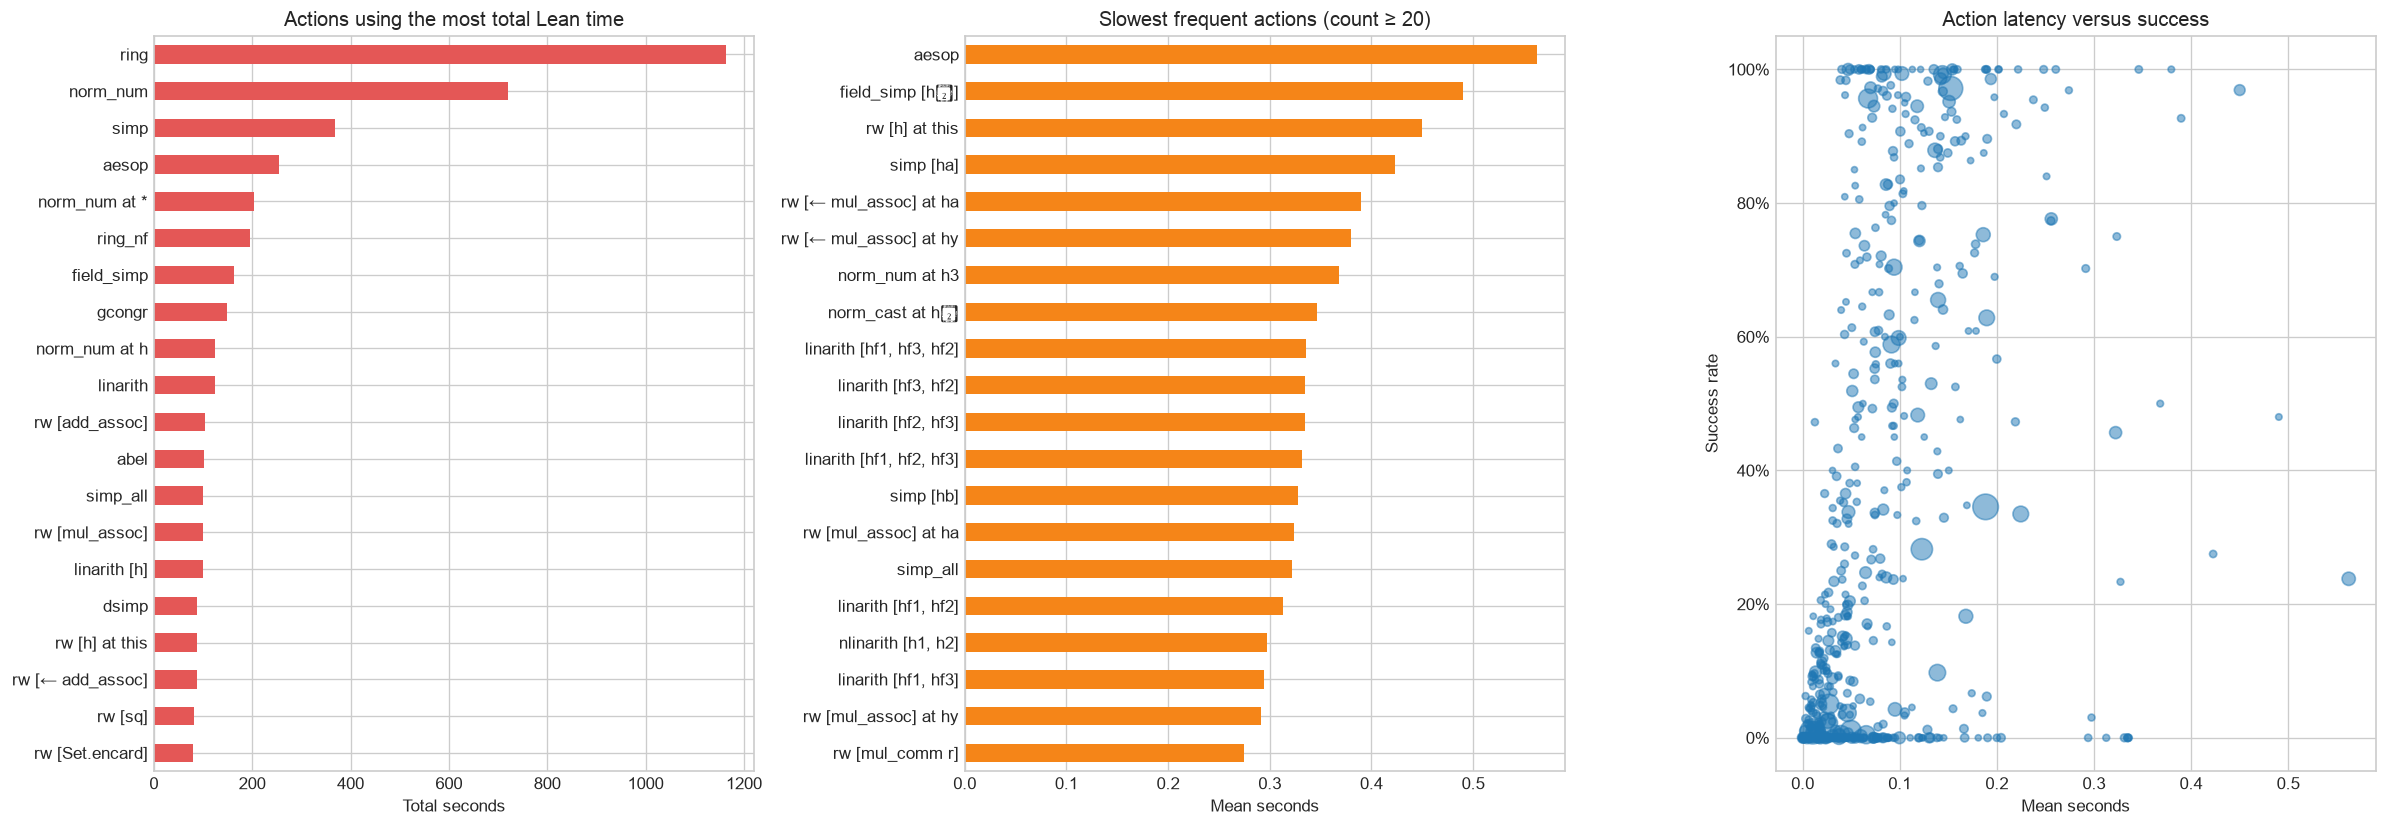

In [9]:
tactic_summary = tactics.groupby('tactic').agg(
    count=('count', 'sum'),
    successful_count=('successful_count', 'sum'),
    total_seconds=('total_seconds', 'sum'),
    min_seconds=('min_seconds', 'min'),
    max_seconds=('max_seconds', 'max'),
).reset_index()
tactic_summary['average_seconds'] = tactic_summary['total_seconds'] / tactic_summary['count']
tactic_summary['success_rate'] = tactic_summary['successful_count'] / tactic_summary['count']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
tactic_summary.nlargest(20, 'total_seconds').sort_values('total_seconds').plot.barh(x='tactic', y='total_seconds', legend=False, ax=axes[0], color='#e45756')
axes[0].set(title='Actions using the most total Lean time', xlabel='Total seconds', ylabel='')
frequent = tactic_summary[tactic_summary['count'] >= 20]
frequent.nlargest(20, 'average_seconds').sort_values('average_seconds').plot.barh(x='tactic', y='average_seconds', legend=False, ax=axes[1], color='#f58518')
axes[1].set(title='Slowest frequent actions (count ≥ 20)', xlabel='Mean seconds', ylabel='')
axes[2].scatter(frequent['average_seconds'], frequent['success_rate'], s=np.sqrt(frequent['count']) * 3, alpha=0.5)
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].set(title='Action latency versus success', xlabel='Mean seconds', ylabel='Success rate')
plt.tight_layout()

print('All individual per-game action aggregates, slowest first:')
print(tactics.nlargest(50, 'max_seconds')[['game', 'tactic', 'count', 'successful_count', 'total_seconds', 'average_seconds', 'min_seconds', 'max_seconds']].to_string(index=False))
print('\nGlobal action summary, largest total cost first:')
print(tactic_summary.nlargest(50, 'total_seconds').to_string(index=False, float_format='{:.4f}'.format))


## Learner loss, replay buffer, and fixed-theorem validation


Replay transitions: 43 (2 validation, 41 training)

Most common replay actions:
action
norm_num                                   5
omega                                      4
simp                                       4
linarith [h]                               3
rw [h]                                     1
linarith [h1, h2]                          1
ext                                        1
constructor                                1
rintro ⟨_, _, _, _, rfl, rfl, rfl, rfl⟩    1
ring                                       1
norm_num at *                              1
field_simp                                 1
rintro rfl                                 1
use 17                                     1
rcases Nat.eq_zero_or_pos n with h | h     1
simp [h] at h₁                             1
cases h                                    1
revert h₁                                  1
simp [h₁]                                  1
norm_num at h₁                             1
rw [hg]      

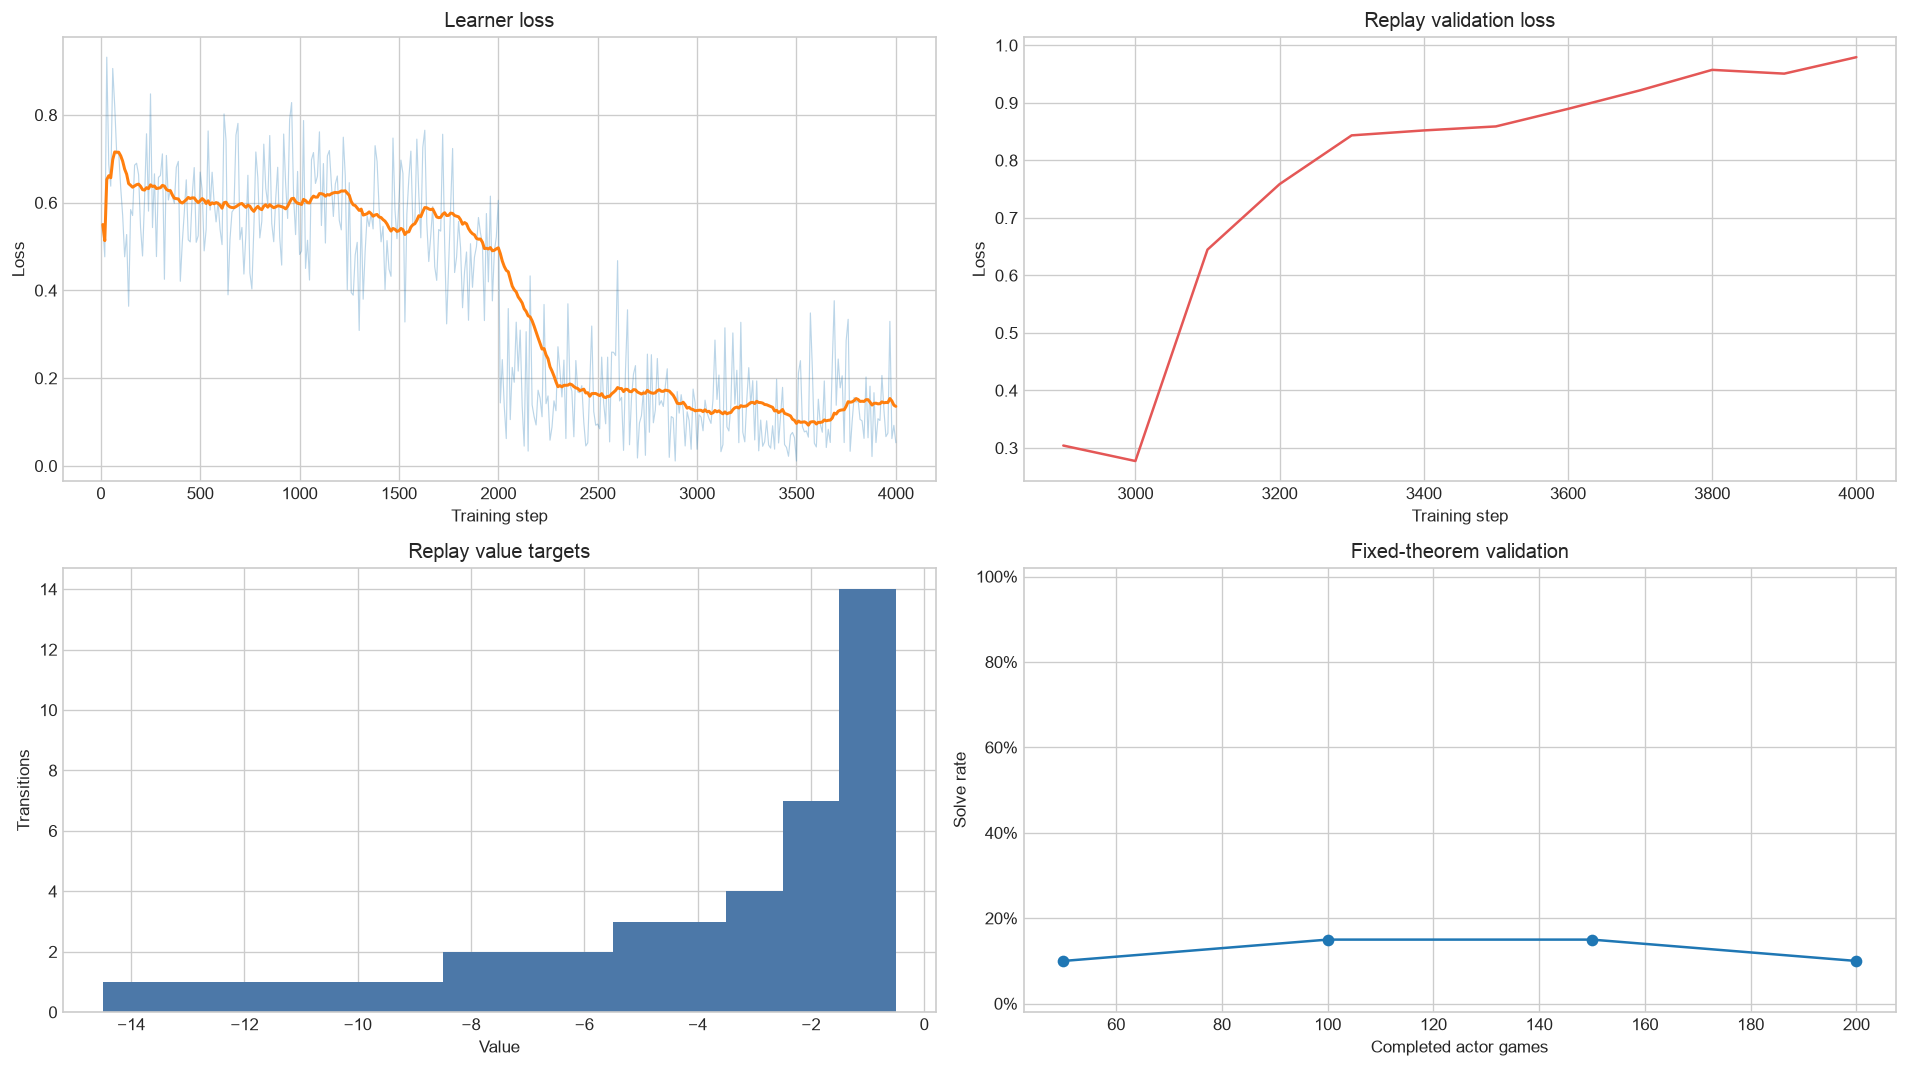

In [10]:
learner_history = history[history['learner/step'].notna()].copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].plot(learner_history['learner/step'], learner_history['train/loss'], alpha=0.3, linewidth=0.7)
axes[0, 0].plot(learner_history['learner/step'], learner_history['train/loss'].rolling(30, min_periods=1).mean(), linewidth=1.8)
axes[0, 0].set(title='Learner loss', xlabel='Training step', ylabel='Loss')
replay_validation = learner_history.dropna(subset=['replay_validation/loss'])
axes[0, 1].plot(replay_validation['learner/step'], replay_validation['replay_validation/loss'], color='#e45756')
axes[0, 1].set(title='Replay validation loss', xlabel='Training step', ylabel='Loss')
axes[1, 0].hist(replay['value'], bins=np.arange(replay['value'].min() - 0.5, replay['value'].max() + 1.5), color='#4c78a8')
axes[1, 0].set(title='Replay value targets', xlabel='Value', ylabel='Transitions')
if not validation.empty:
    axes[1, 1].plot(validation['game'], validation['solve_rate'], marker='o', label='solve rate')
    axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[1, 1].set(title='Fixed-theorem validation', xlabel='Completed actor games', ylabel='Solve rate', ylim=(-0.02, 1.02))
plt.tight_layout()

print(f'Replay transitions: {len(replay):,} ({replay["validation"].sum():,} validation, {(~replay["validation"]).sum():,} training)')
print('\nMost common replay actions:')
print(replay['action'].value_counts().head(30).to_string())
print('\nReplay value distribution:')
print(replay['value'].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).to_string())
print('\nFixed-theorem validation records:')
print(validation.to_string(index=False))


## Matchmaker state and automated conclusion


dataset theorems      61711
attempted theorems      206
invalid theorems         10
total attempts          206
total successes          11

Most attempted theorems:
 attempts  successes  success_rate  invalid                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

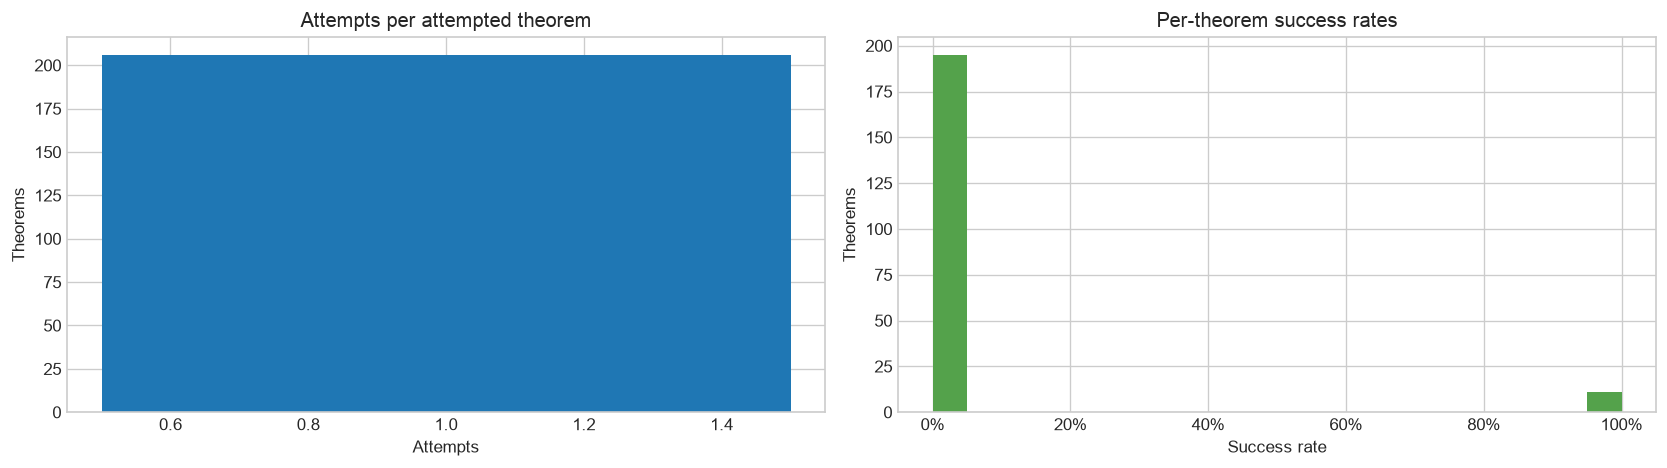

In [11]:
attempted = matchmaker_df[matchmaker_df['attempts'] > 0].copy()
attempted['success_rate'] = attempted['successes'] / attempted['attempts']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(attempted['attempts'], bins=range(1, int(attempted['attempts'].max()) + 2), align='left')
axes[0].set(title='Attempts per attempted theorem', xlabel='Attempts', ylabel='Theorems')
axes[1].hist(attempted['success_rate'], bins=np.linspace(0, 1, 21), color='#54a24b')
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set(title='Per-theorem success rates', xlabel='Success rate', ylabel='Theorems')
plt.tight_layout()

print(pd.Series({
    'dataset theorems': len(matchmaker_df),
    'attempted theorems': len(attempted),
    'invalid theorems': int(matchmaker_df['invalid'].sum()),
    'total attempts': int(matchmaker_df['attempts'].sum()),
    'total successes': int(matchmaker_df['successes'].sum()),
}).to_string())
print('\nMost attempted theorems:')
print(attempted.nlargest(20, 'attempts')[['attempts', 'successes', 'success_rate', 'invalid', 'theorem']].to_string(index=False))

lean_percent = 100 * resource_seconds['Lean / CPU-dominated'] / resource_seconds.sum()
gpu_percent = 100 * resource_seconds['GPU inference + training'] / resource_seconds.sum()
gpu_actor_util = system.loc[system['phase'] == 'actor', 'gpu.0.gpu'].mean()
gpu_learner_util = system.loc[system['phase'] == 'learner', 'gpu.0.gpu'].mean()
gpu_validation_util = system.loc[system['phase'] == 'validation', 'gpu.0.gpu'].mean()
winner = 'Lean / CPU-dominated work' if lean_percent > gpu_percent else 'GPU inference and training'
print('\nAUTOMATED CONCLUSION')
print(f'{winner} took the most wall time in {RUN_NAME}.')
print(f'Estimated split: Lean/CPU-dominated {lean_percent:.1f}% versus GPU inference/training {gpu_percent:.1f}%.')
print(f'Mean GPU utilization: actor {gpu_actor_util:.1f}%, validation {gpu_validation_util:.1f}%, learner {gpu_learner_util:.1f}%.')
print(f'LSF CPU time / wall time: {lsf_resources["CPU time"] / lsf_resources["Run time"]:.2f} effective CPU cores on average.')
print('Caveat: validation is classified as CPU-dominated from its low GPU utilization because per-validation-game component timers were not persisted.')
